**Introduction : Objectif et Méthodologie**

L'objectif de cette étude est d'accompagner une entreprise de commerce électronique dans son arbitrage stratégique entre son application mobile et son site Web. Pour ce faire, nous avons adopté une démarche de Data Mining basée sur l'apprentissage supervisé.

Après une phase d'exploration descriptive des données de 500 clients, nous avons prétraité le dataset en isolant les variables numériques pertinentes (Duree_session, Temps_application, Temps_Web, Duree_Adhesion) pour prédire la variable cible : le 'Montant' annuel dépensé. La construction d'un modèle de régression linéaire, entraîné sur 70 % des données et testé sur les 30 % restants, nous a permis de quantifier l'influence précise de chaque canal de vente sur le chiffre d'affaires.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Etude descriptive de la table de données** : L'étude descriptive permet de comprendre la structure,
la distribution et les caractéristiques générales des données
avant toute modélisation.

In [ ]:
#Importation de la table de données, Affichage des cinqs premieres lignes:
df = pd.read_csv('/content/Clients_Ecommerce.csv')
display(df.head())

,Email,Addresse,Avatar,Duree_session,Temps_application,Temps_Web,Duree_Adhesion,Montant
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [ ]:
#Information relatives aux données de la table

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Email              500 non-null    object 
 1   Addresse           500 non-null    object 
 2   Avatar             500 non-null    object 
 3   Duree_session      500 non-null    float64
 4   Temps_application  500 non-null    float64
 5   Temps_Web          500 non-null    float64
 6   Duree_Adhesion     500 non-null    float64
 7   Montant            500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [ ]:
# Statistiques descriptives des variables de table de données
df.describe()


,Duree_session,Temps_application,Temps_Web,Duree_Adhesion,Montant_
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [ ]:
print(df.describe())

       Duree_session  Temps_application   Temps_Web  Duree_Adhesion  \
count     500.000000         500.000000  500.000000      500.000000   
mean       33.053194          12.052488   37.060445        3.533462   
std         0.992563           0.994216    1.010489        0.999278   
min        29.532429           8.508152   33.913847        0.269901   
25%        32.341822          11.388153   36.349257        2.930450   
50%        33.082008          11.983231   37.069367        3.533975   
75%        33.711985          12.753850   37.716432        4.126502   
max        36.139662          15.126994   40.005182        6.922689   

         Montant_  
count  500.000000  
mean   499.314038  
std     79.314782  
min    256.670582  
25%    445.038277  
50%    498.887875  
75%    549.313828  
max    765.518462  


In [ ]:
df.columns

Index(['Email', 'Addresse', 'Avatar', 'Duree_session', 'Temps_application',
       'Temps_Web', 'Duree_Adhesion', 'Montant_'],
      dtype='object')

In [ ]:
## Supprimer les espaces dans les noms de colonnes
df.columns = df.columns.str.replace(' ', '_')

/tmp/ipykernel_19023/3228022133.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Montant_'])


<Axes: xlabel='Montant_', ylabel='Density'>

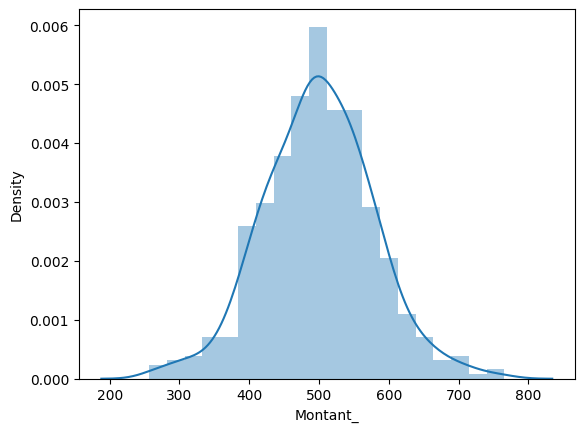

In [ ]:
# Etude de la distribution observée de la variable cible
sns.distplot(df['Montant_'])

**Etude de la dépendance linéaire entre les variables de la table**

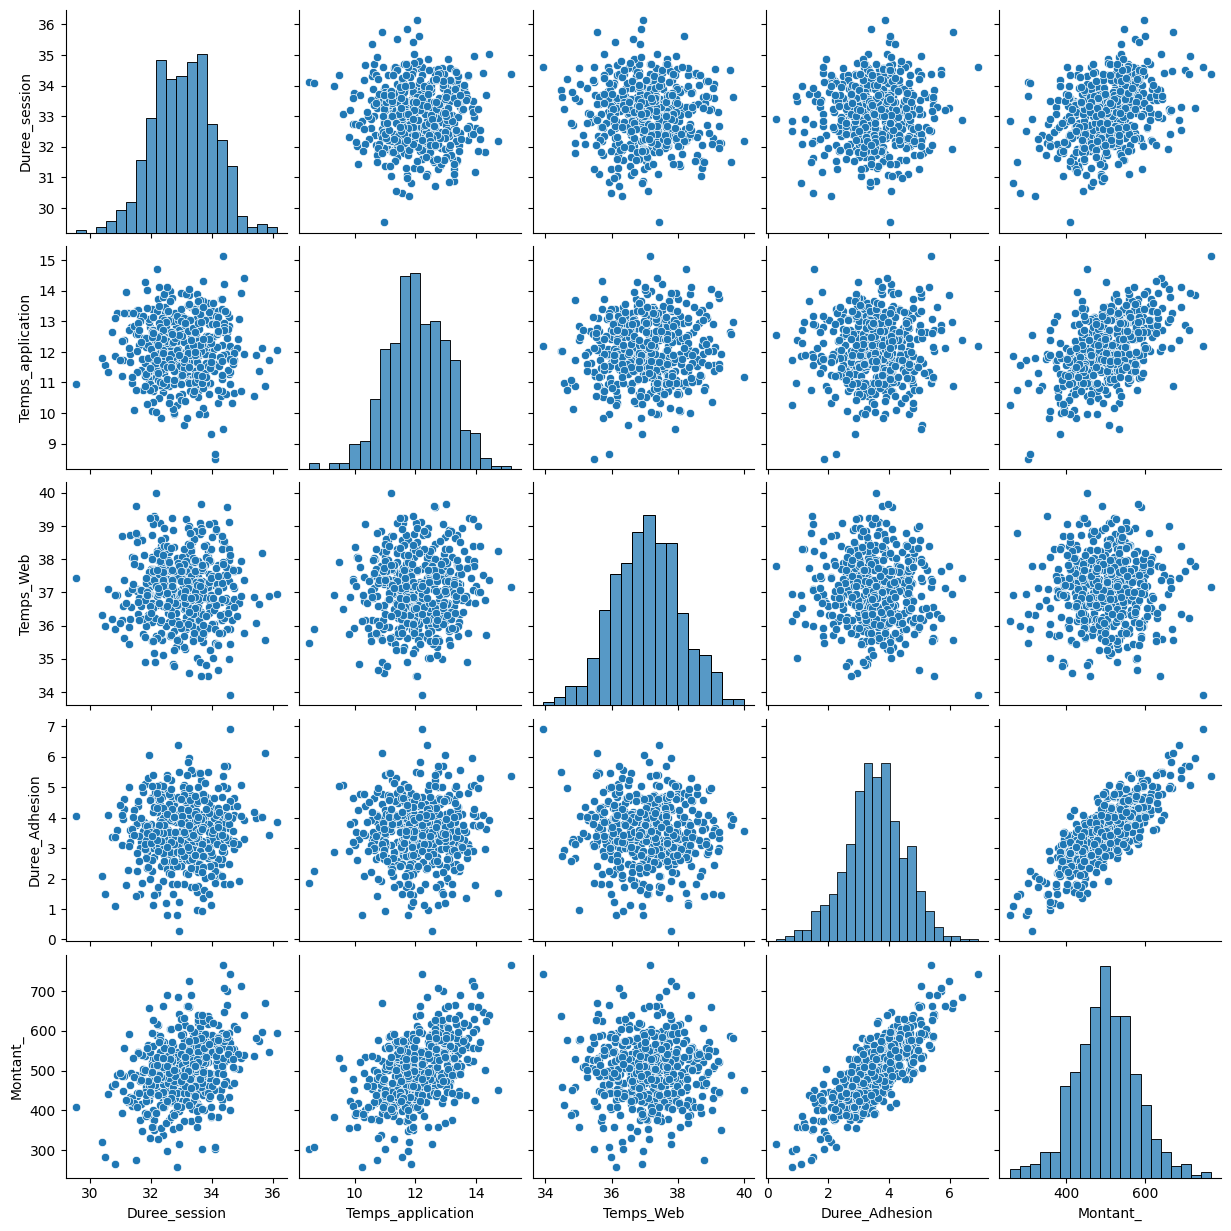

In [ ]:
# Graphiques des distributions observées des variables et ceux des nuages de points
sns.pairplot(df)

On remarque une relation linéaire positive entre la Duree d'adhesion d'un client et le Montant, ce qui indique que **plus la durée d'adhesion d'un client est longue, plus le montant qu'il dépense tend à être élevé**

/tmp/ipykernel_19023/4201125956.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Duree_Adhesion'])


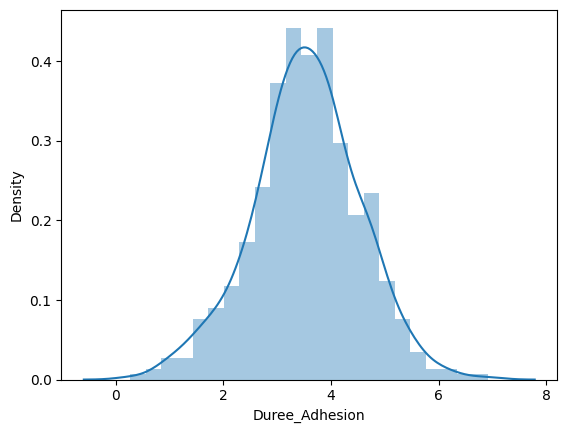

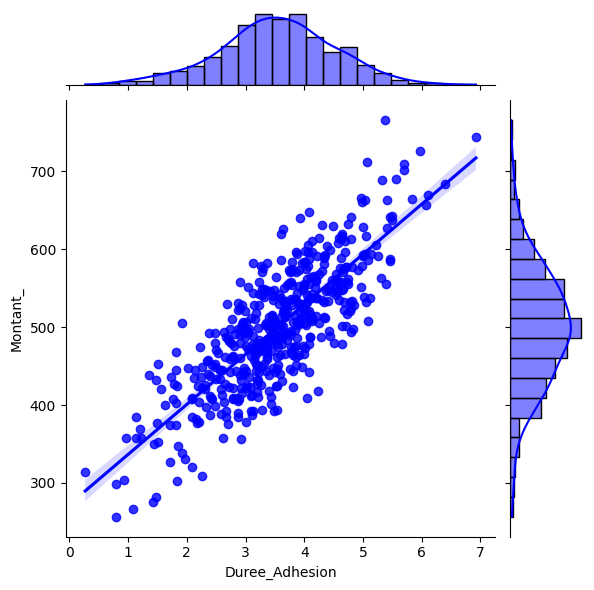

In [ ]:
# Jointplot pour Duree_Adhesion vs Montant_
sns.distplot(df['Duree_Adhesion'])
sns.jointplot(x='Duree_Adhesion', y='Montant_', kind="reg",color='b', data=df)

/tmp/ipykernel_19023/3261954857.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Temps_application'])


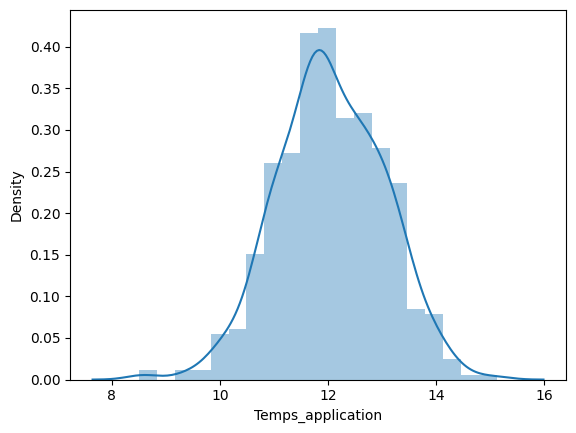

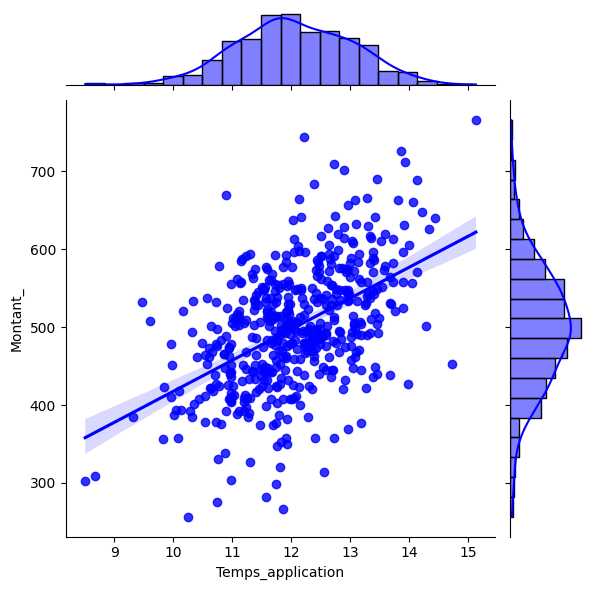

In [ ]:
# Jointplot pour Temps_application vs Montant_
sns.distplot(df['Temps_application'])
sns.jointplot(x='Temps_application', y='Montant_',kind="reg",color='b', data=df)

/tmp/ipykernel_19023/3213323028.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Duree_session'])


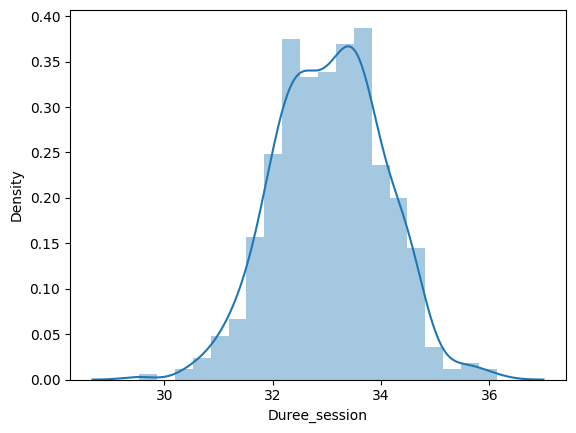

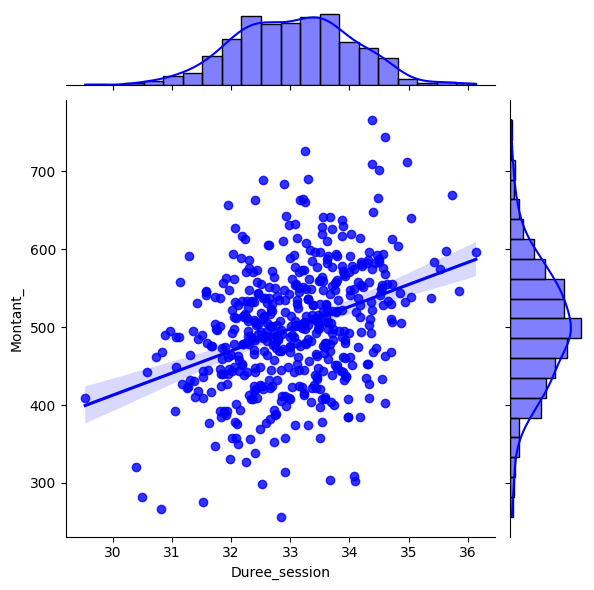

In [ ]:
# Jointplot pour Duree_session vs Montant_
sns.distplot(df['Duree_session'])
sns.jointplot(x='Duree_session', y='Montant_',kind="reg",color='b', data=df)

                   Duree_session  Temps_application  Temps_Web  \
Duree_session           1.000000          -0.027826  -0.034987   
Temps_application      -0.027826           1.000000   0.082388   
Temps_Web              -0.034987           0.082388   1.000000   
Duree_Adhesion          0.060247           0.029143  -0.047582   
Montant_                0.355088           0.499328  -0.002641   

                   Duree_Adhesion  Montant_  
Duree_session            0.060247  0.355088  
Temps_application        0.029143  0.499328  
Temps_Web               -0.047582 -0.002641  
Duree_Adhesion           1.000000  0.809084  
Montant_                 0.809084  1.000000  


<Axes: >

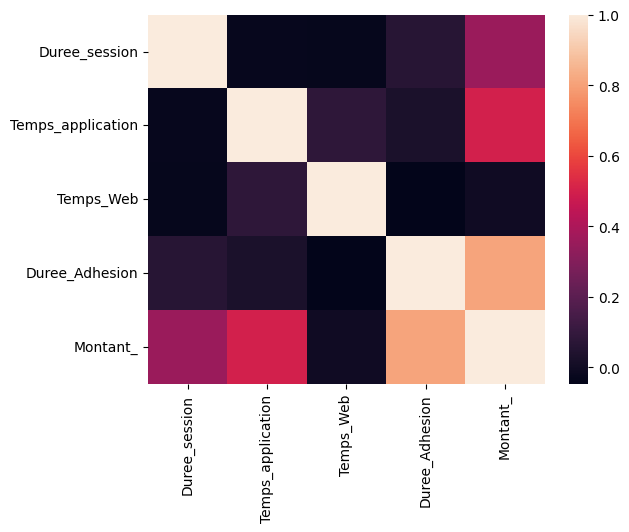

In [ ]:
# Calcul des coefficients de correlation pour les colonnes numériques
corr_df = df.select_dtypes(include=['float64', 'int64']).corr()
print(corr_df)
sns.heatmap(corr_df)

**Mise en oeuvre de la régression linéaire avec statsmodels**

In [ ]:
#importation du package permettant de réaliser un modèle de régression linéaire
import statsmodels.formula.api as smf

#déclaration du modèle
reg_linear = smf.ols(formula='Montant_ ~ Duree_Adhesion + Temps_application + Duree_session', data=df)

#lancement des calculs
resultat_reg = reg_linear.fit()
# Affichage des résultats
print(resultat_reg.summary())

                            OLS Regression Results                            
Dep. Variable:               Montant_   R-squared:                       0.984
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                 1.036e+04
Date:                Sun, 03 May 2026   Prob (F-statistic):               0.00
Time:                        11:39:16   Log-Likelihood:                -1857.4
No. Observations:                 500   AIC:                             3723.
Df Residuals:                     496   BIC:                             3740.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -1035.3396     15.98

**Apprentissage par régression linéaire:**

Structuration des Données (Features & Target)Le dataset est segmenté pour isoler les indicateurs comportementaux du résultat financier :  Vecteur cible ($y$) : Variable 'Montant' représentant la dépense annuelle.
  
  **Matrice des caractéristiques ($X$) :**
   Regroupe 'Duree_session', 'Temps_application', 'Temps_Web' et 'Duree_Adhesion'.

** Nettoyage appliqué:**

Filtrage : Élimination des colonnes textuelles ('Email', 'Addresse', 'Avatar') inexploitables par l'algorithme de régression.  

Formatage : Les noms de colonnes ont été nettoyés pour garantir une manipulation précise du vecteur cible.  

In [ ]:
# Sélection des prédicteurs et de la cible
X = df[['Duree_session', 'Temps_application', 'Temps_Web', 'Duree_Adhesion']]
y = df['Montant_']

## Echantillons d'Apprentissage et de Test

**Échantillon d'apprentissage (70%) : **350 clients servent à "entraîner" le modèle pour qu'il apprenne les relations entre les caractéristiques et le montant dépensé.

**Échantillon de test (30%) :** 150 clients sont conservés pour évaluer la performance réelle du modèle sur des données qu'il n'a jamais vues auparavant.

In [ ]:
from sklearn.model_selection import train_test_split
# Séparation des données : 70% pour l'entraînement, 30% pour le test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

**Elaboration et entrainement du modèle**

In [ ]:
from sklearn.linear_model import LinearRegression
print(LinearRegression)
lm = LinearRegression()

<class 'sklearn.linear_model._base.LinearRegression'>


In [ ]:
lm.fit(X_train,y_train)

LinearRegression()

**Evaluation de la qualité du modèle et validation du modèle**

Évaluons le modèle en vérifiant ses coefficients et comment nous pouvons les interpréter.

In [ ]:
# print the intercept
print(lm.intercept_)

-1047.9327822502391


In [ ]:
print(lm.coef_)

[25.98154972 38.59015875  0.19040528 61.27909654]


In [ ]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
Duree_session,25.981550
Temps_application,38.590159
Temps_Web,0.190405
Duree_Adhesion,61.279097



**Interprétation des Coefficients de Régression**

Les coefficients indiquent l'impact de chaque variable sur le Montant annuel dépensé, toutes choses égales par ailleurs :  

**Duree_session (25,98) :** Une augmentation d'une unité de la durée de session en magasin entraîne une hausse de 25,98 $ des dépenses.  

**Temps_application (38,59) :** Chaque minute supplémentaire passée sur l'application mobile génère un gain de 38,59 $.  

**Temps_Web (0,19) :** L'impact du site Web est négligeable, n'ajoutant que 0,19 $ par minute supplémentaire.  

**Duree_Adhesion (61,28) : ** C'est le facteur le plus influent ; chaque année d'ancienneté supplémentaire rapporte 61,28 $.  

**Conclusion compacte : **
L'application mobile est nettement plus rentable que le site Web. La fidélisation client (Adhésion) reste toutefois le levier de croissance prioritaire

**Predictions à partir de notre Modèle**
Considérons les prédictions pour notre échantillon de test et évaluons la qualité de ces prédictions.

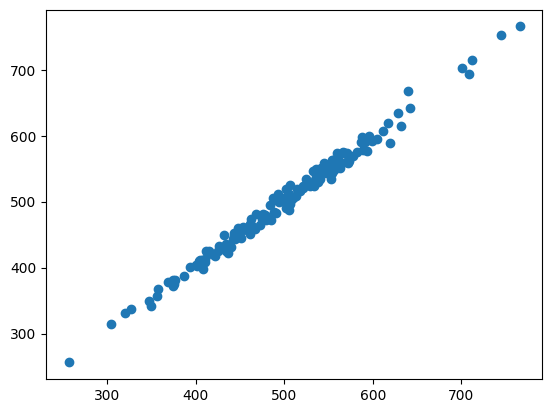

In [ ]:
plt.scatter(y_test,predictions)

**Histogramme des résidus**

/tmp/ipykernel_19023/1326397652.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot((y_test-predictions),bins=50);


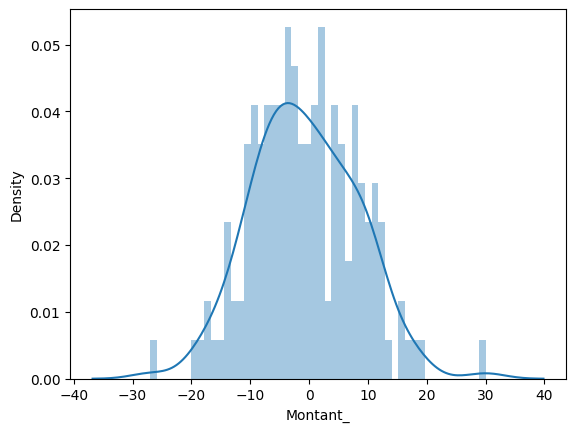

In [ ]:
sns.distplot((y_test-predictions),bins=50);

**Évaluation de la performance du modèlePour quantifier la précision de nos prédictions du Montant annuel**, **nous utilisons les métriques suivantes :**

**MAE (Mean Absolute Error) : 7,23. ** En moyenne, nos prédictions s'écartent de la réalité de seulement 7,23 $.

**MSE (Mean Squared Error) : 79,81. ** Cette valeur pénalise les erreurs plus importantes.

**RMSE (Root Mean Squared Error) : 8,93.** L'erreur type est d'environ 8,93 $, ce qui est extraimement faible par rapport a la moyenne de depenses (~500dollars) .

**R² (Coefficient de détermination) : 0,9890.** Le modèle explique 98,9% de la variance des dépenses clients, ce qui indique une excellente fiabilité.


In [ ]:
from sklearn import metrics

In [ ]:
# Calcul des prédictions
predictions = lm.predict(X_test)

# Calcul et affichage des métriques
print('MAE  :', metrics.mean_absolute_error(y_test, predictions))
print('MSE  :', metrics.mean_squared_error(y_test, predictions))
print('RMSE :', np.sqrt(metrics.mean_squared_error(y_test, predictions)))
print('R²   :', metrics.r2_score(y_test, predictions))

MAE  : 7.228148653430826
MSE  : 79.81305165097427
RMSE : 8.933815066978624
R²   : 0.9890046246741234


**CONCLUSION:**

Après avoir fait tourner le modèle, les chiffres parlent d'eux-mêmes :
L'application mobile écrase le site Web : Chaque minute passée sur l'appli rapporte environ 38 dollars, alors que sur le site Web, on est à peine à 0,19 dollars. C'est le jour et la nuit. Si l'entreprise doit investir, c'est dans l'appli sans aucune hésitation.  La fidélité, c'est le vrai moteur : Ce qui fait vraiment grimper la facture, c'est l'ancienneté du client (Duree_Adhesion). Un client fidèle dépense beaucoup plus qu'un nouveau venu.  On est dans le vrai : Notre modèle est ultra-précis avec un score de 99% (R²). Les prédictions qu'on obtient sont à 8 dollars près de la réalité, ce qui est excellent pour un panier moyen de 500 dollars.

**Conseil final: ** Mettez tous vos efforts sur l'application mobile pour booster les ventes immédiates, tout en soignant vos clients fidèles pour assurer le long terme.  